<a href="https://colab.research.google.com/github/Bryan-Kweku-Wilson/Machine-Learning-Projects/blob/main/EcoCell_RL_03_Energy_QoS_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
traffic_df = pd.read_csv("ecocell_traffic.csv")

traffic_df.head()

,timestamp,bs_id,cell_type,traffic_mbps,active_users,capacity_mbps,utilization,throughput_mbps,packet_loss_rate,latency_ms,traffic_spike
0,2026-01-01 00:00:00,BS00,urban,34.394687,17,984.792314,0.034926,34.394687,0.003310,18.827108,False
1,2026-01-01 00:00:00,BS01,rural,29.212211,15,887.566412,0.032913,29.212211,0.009014,20.964499,False
2,2026-01-01 00:00:00,BS02,suburban,38.916347,19,969.749471,0.040130,38.916347,0.002017,18.629819,False
3,2026-01-01 00:00:00,BS03,suburban,33.128630,17,947.413675,0.034967,33.128630,0.001163,23.756477,False
4,2026-01-01 00:00:00,BS04,urban,18.615690,9,798.949989,0.023300,18.615690,0.002295,21.127977,False


In [ ]:
print("Rows:", len(traffic_df))
print("Columns:", len(traffic_df.columns))

print("\nColumns:")
print(traffic_df.columns.tolist())

traffic_df.info()

Rows: 36000
Columns: 11

Columns:
['timestamp', 'bs_id', 'cell_type', 'traffic_mbps', 'active_users', 'capacity_mbps', 'utilization', 'throughput_mbps', 'packet_loss_rate', 'latency_ms', 'traffic_spike']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36000 entries, 0 to 35999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   timestamp         36000 non-null  object 
 1   bs_id             36000 non-null  object 
 2   cell_type         36000 non-null  object 
 3   traffic_mbps      36000 non-null  float64
 4   active_users      36000 non-null  int64  
 5   capacity_mbps     36000 non-null  float64
 6   utilization       36000 non-null  float64
 7   throughput_mbps   36000 non-null  float64
 8   packet_loss_rate  36000 non-null  float64
 9   latency_ms        36000 non-null  float64
 10  traffic_spike     36000 non-null  bool   
dtypes: bool(1), float64(6), int64(1), object(3)
memory usage: 2.8+ MB


In [ ]:
POWER_STATES = {
    "active": 1.00,
    "light_sleep": 0.40,
    "deep_sleep": 0.10
}

POWER_STATES

{'active': 1.0, 'light_sleep': 0.4, 'deep_sleep': 0.1}

In [ ]:
IDLE_POWER_RATIO = 0.60

traffic_df["idle_power_w"] = (
    traffic_df["capacity_mbps"] * 0
)

Merge network power **information**

In [ ]:
network_df = pd.read_csv("ecocell_network.csv")

network_df[
    [
        "bs_id",
        "capacity_mbps",
        "baseline_power_w"
    ]
].head()

,bs_id,capacity_mbps,baseline_power_w
0,BS00,984.792314,1435.786120
1,BS01,887.566412,967.693323
2,BS02,969.749471,901.426410
3,BS03,947.413675,1142.616932
4,BS04,798.949989,1489.955318


In [ ]:
traffic_df = traffic_df.merge(
    network_df[
        [
            "bs_id",
            "baseline_power_w"
        ]
    ],
    on="bs_id",
    how="left"
)

traffic_df.head()

,timestamp,bs_id,cell_type,traffic_mbps,active_users,capacity_mbps,utilization,throughput_mbps,packet_loss_rate,latency_ms,traffic_spike,idle_power_w,baseline_power_w
0,2026-01-01 00:00:00,BS00,urban,34.394687,17,984.792314,0.034926,34.394687,0.003310,18.827108,False,0.0,1435.786120
1,2026-01-01 00:00:00,BS01,rural,29.212211,15,887.566412,0.032913,29.212211,0.009014,20.964499,False,0.0,967.693323
2,2026-01-01 00:00:00,BS02,suburban,38.916347,19,969.749471,0.040130,38.916347,0.002017,18.629819,False,0.0,901.426410
3,2026-01-01 00:00:00,BS03,suburban,33.128630,17,947.413675,0.034967,33.128630,0.001163,23.756477,False,0.0,1142.616932
4,2026-01-01 00:00:00,BS04,urban,18.615690,9,798.949989,0.023300,18.615690,0.002295,21.127977,False,0.0,1489.955318


In [ ]:
IDLE_POWER_RATIO = 0.60

traffic_df["idle_power_w"] = (
    traffic_df["baseline_power_w"]
    * IDLE_POWER_RATIO
)

traffic_df["active_power_w"] = (
    traffic_df["idle_power_w"]
    +
    (
        traffic_df["baseline_power_w"]
        - traffic_df["idle_power_w"]
    )
    * traffic_df["utilization"]
)

traffic_df[
    [
        "bs_id",
        "utilization",
        "baseline_power_w",
        "active_power_w"
    ]
].head()

,bs_id,utilization,baseline_power_w,active_power_w
0,BS00,0.034926,1435.786120,881.530079
1,BS01,0.032913,967.693323,593.355756
2,BS02,0.040130,901.426410,555.325655
3,BS03,0.034967,1142.616932,701.551914
4,BS04,0.023300,1489.955318,907.859690


In [ ]:
traffic_df["light_sleep_power_w"] = (
    traffic_df["baseline_power_w"]
    * POWER_STATES["light_sleep"]
)

traffic_df["deep_sleep_power_w"] = (
    traffic_df["baseline_power_w"]
    * POWER_STATES["deep_sleep"]
)

traffic_df[
    [
        "bs_id",
        "baseline_power_w",
        "active_power_w",
        "light_sleep_power_w",
        "deep_sleep_power_w"
    ]
].head()

,bs_id,baseline_power_w,active_power_w,light_sleep_power_w,deep_sleep_power_w
0,BS00,1435.786120,881.530079,574.314448,143.578612
1,BS01,967.693323,593.355756,387.077329,96.769332
2,BS02,901.426410,555.325655,360.570564,90.142641
3,BS03,1142.616932,701.551914,457.046773,114.261693
4,BS04,1489.955318,907.859690,595.982127,148.995532


In [ ]:
traffic_df["active_energy_kwh"] = (
    traffic_df["active_power_w"] / 1000
)

In [ ]:
traffic_df["light_sleep_energy_kwh"] = (
    traffic_df["light_sleep_power_w"] / 1000
)

traffic_df["deep_sleep_energy_kwh"] = (
    traffic_df["deep_sleep_power_w"] / 1000
)

In [ ]:
traffic_df["light_sleep_savings_kwh"] = (
    traffic_df["active_energy_kwh"]
    - traffic_df["light_sleep_energy_kwh"]
)

traffic_df["deep_sleep_savings_kwh"] = (
    traffic_df["active_energy_kwh"]
    - traffic_df["deep_sleep_energy_kwh"]
)

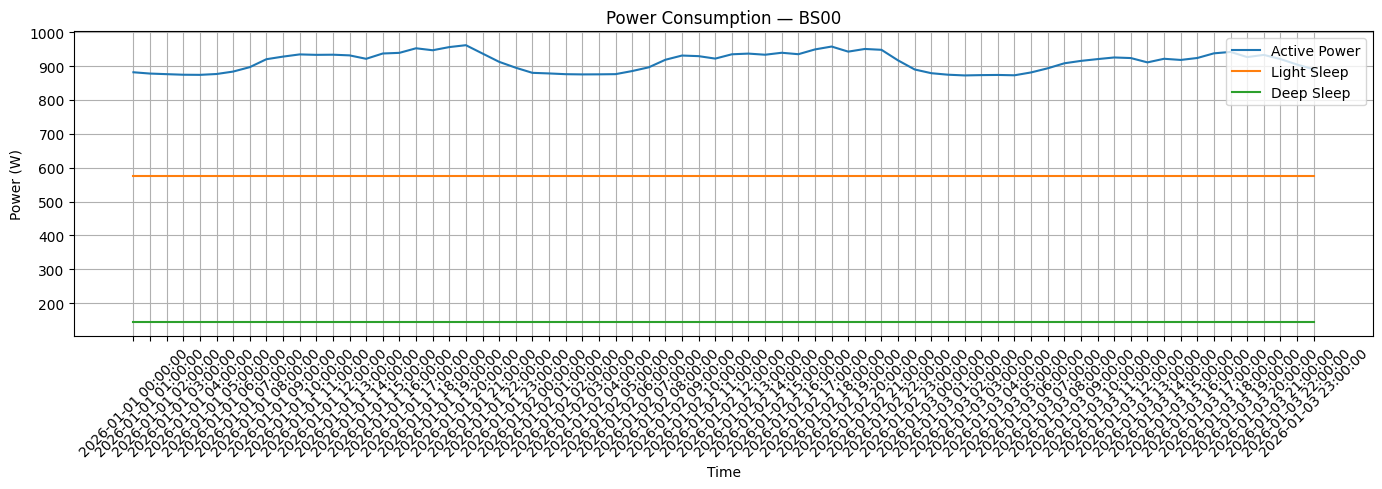

In [ ]:
sample_bs = "BS00"

sample_data = traffic_df[
    traffic_df["bs_id"] == sample_bs
].iloc[:72]

plt.figure(figsize=(14, 5))

plt.plot(
    sample_data["timestamp"],
    sample_data["active_power_w"],
    label="Active Power"
)

plt.plot(
    sample_data["timestamp"],
    sample_data["light_sleep_power_w"],
    label="Light Sleep"
)

plt.plot(
    sample_data["timestamp"],
    sample_data["deep_sleep_power_w"],
    label="Deep Sleep"
)

plt.title(f"Power Consumption — {sample_bs}")
plt.xlabel("Time")
plt.ylabel("Power (W)")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import networkx as nx

In [ ]:
G = nx.Graph()

for _, bs in network_df.iterrows():
    G.add_node(
        bs["bs_id"],
        cell_type=bs["cell_type"],
        capacity_mbps=bs["capacity_mbps"],
        baseline_power_w=bs["baseline_power_w"]
    )

ROWS = 5
COLS = 10

for row in range(ROWS):
    for col in range(COLS):

        current = row * COLS + col

        if col < COLS - 1:
            right = current + 1
            G.add_edge(
                f"BS{current:02d}",
                f"BS{right:02d}"
            )

        if row < ROWS - 1:
            below = current + COLS
            G.add_edge(
                f"BS{current:02d}",
                f"BS{below:02d}"
            )

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 50
Number of edges: 85


In [ ]:
sample_bs = "BS22"

neighbors = list(G.neighbors(sample_bs))

print(f"Neighbors of {sample_bs}:")
print(neighbors)

Neighbors of BS22:
['BS12', 'BS21', 'BS23', 'BS32']


In [ ]:
def redistribute_traffic(
    sleeping_bs,
    traffic_amount,
    active_bs_set,
    graph
):
    neighbors = list(graph.neighbors(sleeping_bs))

    active_neighbors = [
        bs for bs in neighbors
        if bs in active_bs_set
    ]

    if len(active_neighbors) == 0:
        return {}

    traffic_per_neighbor = (
        traffic_amount / len(active_neighbors)
    )

    redistribution = {
        bs: traffic_per_neighbor
        for bs in active_neighbors
    }

    return redistribution

In [ ]:
active_bs_set = set(network_df["bs_id"])

result = redistribute_traffic(
    sleeping_bs="BS22",
    traffic_amount=300,
    active_bs_set=active_bs_set,
    graph=G
)

print(result)

{'BS12': 75.0, 'BS21': 75.0, 'BS23': 75.0, 'BS32': 75.0}


In [ ]:
def calculate_updated_utilization(
    original_traffic,
    capacity,
    additional_traffic=0
):
    total_traffic = (
        original_traffic
        + additional_traffic
    )

    utilization = (
        total_traffic / capacity
    )

    return utilization

In [ ]:
original_traffic = 400
capacity = 500
additional_traffic = 100

new_utilization = calculate_updated_utilization(
    original_traffic,
    capacity,
    additional_traffic
)

print("New utilization:", new_utilization)
print("New utilization (%):", new_utilization * 100)

New utilization: 1.0
New utilization (%): 100.0


In [ ]:
test_timestamp = traffic_df["timestamp"].iloc[0]

snapshot = traffic_df[
    traffic_df["timestamp"] == test_timestamp
].copy()

snapshot.head()

,timestamp,bs_id,cell_type,traffic_mbps,active_users,capacity_mbps,utilization,throughput_mbps,packet_loss_rate,latency_ms,...,idle_power_w,baseline_power_w,active_power_w,light_sleep_power_w,deep_sleep_power_w,active_energy_kwh,light_sleep_energy_kwh,deep_sleep_energy_kwh,light_sleep_savings_kwh,deep_sleep_savings_kwh
0,2026-01-01 00:00:00,BS00,urban,34.394687,17,984.792314,0.034926,34.394687,0.003310,18.827108,...,861.471672,1435.786120,881.530079,574.314448,143.578612,0.881530,0.574314,0.143579,0.307216,0.737951
1,2026-01-01 00:00:00,BS01,rural,29.212211,15,887.566412,0.032913,29.212211,0.009014,20.964499,...,580.615994,967.693323,593.355756,387.077329,96.769332,0.593356,0.387077,0.096769,0.206278,0.496586
2,2026-01-01 00:00:00,BS02,suburban,38.916347,19,969.749471,0.040130,38.916347,0.002017,18.629819,...,540.855846,901.426410,555.325655,360.570564,90.142641,0.555326,0.360571,0.090143,0.194755,0.465183
3,2026-01-01 00:00:00,BS03,suburban,33.128630,17,947.413675,0.034967,33.128630,0.001163,23.756477,...,685.570159,1142.616932,701.551914,457.046773,114.261693,0.701552,0.457047,0.114262,0.244505,0.587290
4,2026-01-01 00:00:00,BS04,urban,18.615690,9,798.949989,0.023300,18.615690,0.002295,21.127977,...,893.973191,1489.955318,907.859690,595.982127,148.995532,0.907860,0.595982,0.148996,0.311878,0.758864


In [ ]:
sleeping_bs = "BS22"

active_bs_set = set(
    snapshot["bs_id"]
)

active_bs_set.remove(
    sleeping_bs
)

In [ ]:
sleeping_traffic = snapshot.loc[
    snapshot["bs_id"] == sleeping_bs,
    "traffic_mbps"
].iloc[0]

print(
    "Traffic being transferred:",
    sleeping_traffic,
    "Mbps"
)

Traffic being transferred: 25.69638040754932 Mbps


In [ ]:
redistribution = redistribute_traffic(
    sleeping_bs=sleeping_bs,
    traffic_amount=sleeping_traffic,
    active_bs_set=active_bs_set,
    graph=G
)

print("Traffic redistribution:")
print(redistribution)

Traffic redistribution:
{'BS12': np.float64(6.42409510188733), 'BS21': np.float64(6.42409510188733), 'BS23': np.float64(6.42409510188733), 'BS32': np.float64(6.42409510188733)}


In [ ]:
snapshot["additional_traffic_mbps"] = 0.0

In [ ]:
for bs, additional_traffic in redistribution.items():

    snapshot.loc[
        snapshot["bs_id"] == bs,
        "additional_traffic_mbps"
    ] = additional_traffic

In [ ]:
snapshot["new_traffic_mbps"] = (
    snapshot["traffic_mbps"]
    + snapshot["additional_traffic_mbps"]
)

In [ ]:
snapshot["new_utilization"] = (
    snapshot["new_traffic_mbps"]
    / snapshot["capacity_mbps"]
)

In [ ]:
affected_cells = list(
    redistribution.keys()
)

snapshot[
    snapshot["bs_id"].isin(affected_cells)
][
    [
        "bs_id",
        "traffic_mbps",
        "additional_traffic_mbps",
        "new_traffic_mbps",
        "capacity_mbps",
        "new_utilization"
    ]
]

,bs_id,traffic_mbps,additional_traffic_mbps,new_traffic_mbps,capacity_mbps,new_utilization
12,BS12,24.571783,6.424095,30.995878,914.368755,0.033899
21,BS21,19.952859,6.424095,26.376954,599.357841,0.044009
23,BS23,28.983664,6.424095,35.407759,907.730714,0.039007
32,BS32,16.335729,6.424095,22.759824,665.449012,0.034202


In [ ]:
np.random.seed(42)

snapshot["new_packet_loss_rate"] = np.where(
    snapshot["new_utilization"] < 0.80,

    np.random.uniform(
        0.001,
        0.01,
        len(snapshot)
    ),

    np.where(
        snapshot["new_utilization"] <= 1.0,

        np.random.uniform(
            0.01,
            0.10,
            len(snapshot)
        ),

        np.random.uniform(
            0.10,
            0.30,
            len(snapshot)
        )
    )
)

In [ ]:
snapshot["new_latency_ms"] = (
    20
    + 50 * (
        snapshot["new_utilization"] ** 3
    )
    + np.random.normal(
        0,
        2,
        len(snapshot)
    )
)

snapshot["new_latency_ms"] = (
    snapshot["new_latency_ms"]
    .clip(lower=5)
)

In [ ]:
comparison = snapshot[
    snapshot["bs_id"].isin(
        [sleeping_bs] + affected_cells
    )
][
    [
        "bs_id",
        "traffic_mbps",
        "new_traffic_mbps",
        "utilization",
        "new_utilization",
        "packet_loss_rate",
        "new_packet_loss_rate",
        "latency_ms",
        "new_latency_ms"
    ]
]

comparison

,bs_id,traffic_mbps,new_traffic_mbps,utilization,new_utilization,packet_loss_rate,new_packet_loss_rate,latency_ms,new_latency_ms
12,BS12,24.571783,30.995878,0.026873,0.033899,0.006089,0.008492,19.151692,18.020875
21,BS21,19.952859,26.376954,0.033290,0.044009,0.005573,0.002255,22.490174,23.104131
22,BS22,25.696380,25.696380,0.051111,0.051111,0.005825,0.003629,18.959848,18.440169
23,BS23,28.983664,35.407759,0.031930,0.039007,0.004858,0.004297,17.938844,19.358844
32,BS32,16.335729,22.759824,0.024548,0.034202,0.001772,0.001585,19.378908,17.528099


In [ ]:
snapshot["overload_violation"] = (
    snapshot["new_utilization"] > 1.0
)

snapshot["packet_loss_violation"] = (
    snapshot["new_packet_loss_rate"] > 0.05
)

snapshot["latency_violation"] = (
    snapshot["new_latency_ms"] > 50
)

In [ ]:
snapshot["qos_violation"] = (
    snapshot["overload_violation"]
    |
    snapshot["packet_loss_violation"]
    |
    snapshot["latency_violation"]
)

In [ ]:
print(
    "QoS violations:",
    snapshot["qos_violation"].sum()
)

print(
    "Total base stations:",
    len(snapshot)
)

QoS violations: 0
Total base stations: 50


In [ ]:
qos_violation_rate = (
    snapshot["qos_violation"].mean()
)

print(
    "QoS violation rate:",
    qos_violation_rate * 100,
    "%"
)

QoS violation rate: 0.0 %


In [ ]:
network_energy_active = (
    snapshot["active_power_w"].sum()
    / 1000
)

print(
    "Network energy if all BSs are active:",
    network_energy_active,
    "kWh"
)

Network energy if all BSs are active: 35.764183475149025 kWh


In [ ]:
sleeping_bs_data = snapshot[
    snapshot["bs_id"] == sleeping_bs
].iloc[0]

energy_with_sleep = (
    snapshot["active_power_w"].sum()
    - sleeping_bs_data["active_power_w"]
    + sleeping_bs_data["deep_sleep_power_w"]
) / 1000

print(
    "Energy with one BS in deep sleep:",
    energy_with_sleep,
    "kWh"
)

Energy with one BS in deep sleep: 35.161267001275476 kWh


In [ ]:
energy_savings = (
    network_energy_active
    - energy_with_sleep
)

energy_savings_percentage = (
    energy_savings
    / network_energy_active
    * 100
)

print(
    "Energy savings:",
    energy_savings,
    "kWh"
)

print(
    "Energy savings percentage:",
    energy_savings_percentage,
    "%"
)

Energy savings: 0.6029164738735489 kWh
Energy savings percentage: 1.6858108176647995 %


In [ ]:
network_summary = {
    "timestamp": test_timestamp,
    "network_energy_active_kwh": network_energy_active,
    "network_energy_sleep_kwh": energy_with_sleep,
    "energy_savings_kwh": energy_savings,
    "energy_savings_percent": energy_savings_percentage,
    "qos_violation_rate": qos_violation_rate,
    "sleeping_bs": sleeping_bs
}

network_summary

{'timestamp': '2026-01-01 00:00:00',
 'network_energy_active_kwh': np.float64(35.764183475149025),
 'network_energy_sleep_kwh': np.float64(35.161267001275476),
 'energy_savings_kwh': np.float64(0.6029164738735489),
 'energy_savings_percent': np.float64(1.6858108176647995),
 'qos_violation_rate': np.float64(0.0),
 'sleeping_bs': 'BS22'}

In [ ]:
traffic_df["network_active_energy_kwh"] = (
    traffic_df["active_energy_kwh"]
)

In [ ]:
traffic_df.rename(
    columns={
        "active_energy_kwh":
        "bs_active_energy_kwh"
    },
    inplace=True
)

In [ ]:
traffic_df.to_csv(
    "ecocell_energy_qos.csv",
    index=False
)

print("Stage 3 dataset saved successfully!")
print("Rows:", len(traffic_df))
print("Columns:", len(traffic_df.columns))

Stage 3 dataset saved successfully!
Rows: 36000
Columns: 22


In [ ]:
print(traffic_df.columns.tolist())

['timestamp', 'bs_id', 'cell_type', 'traffic_mbps', 'active_users', 'capacity_mbps', 'utilization', 'throughput_mbps', 'packet_loss_rate', 'latency_ms', 'traffic_spike', 'idle_power_w', 'baseline_power_w', 'active_power_w', 'light_sleep_power_w', 'deep_sleep_power_w', 'bs_active_energy_kwh', 'light_sleep_energy_kwh', 'deep_sleep_energy_kwh', 'light_sleep_savings_kwh', 'deep_sleep_savings_kwh', 'network_active_energy_kwh']


In [ ]:
traffic_df.describe()

,traffic_mbps,active_users,capacity_mbps,utilization,throughput_mbps,packet_loss_rate,latency_ms,idle_power_w,baseline_power_w,active_power_w,light_sleep_power_w,deep_sleep_power_w,bs_active_energy_kwh,light_sleep_energy_kwh,deep_sleep_energy_kwh,light_sleep_savings_kwh,deep_sleep_savings_kwh,network_active_energy_kwh
count,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000
mean,77.636739,38.816556,747.218791,0.107343,77.636739,0.005506,20.138511,697.292682,1162.154470,747.048116,464.861788,116.215447,0.747048,0.464862,0.116215,0.282186,0.630833,0.747048
std,48.778469,24.389684,151.880908,0.070479,48.778469,0.002590,2.013141,120.701890,201.169816,132.743663,80.467926,20.116982,0.132744,0.080468,0.020117,0.058380,0.113374,0.132744
min,6.634526,3.000000,502.761059,0.007536,6.634526,0.001000,12.346367,486.966888,811.611480,492.370572,324.644592,81.161148,0.492371,0.324645,0.081161,0.167726,0.411209,0.492371
25%,30.511746,15.000000,599.357841,0.043101,30.511746,0.003271,18.788727,581.577962,969.296604,628.655325,387.718641,96.929660,0.628655,0.387719,0.096930,0.235735,0.529422,0.628655
50%,75.197968,38.000000,754.132106,0.102023,75.197968,0.005523,20.140403,709.104854,1181.841423,760.189245,472.736569,118.184142,0.760189,0.472737,0.118184,0.281393,0.639603,0.760189
75%,112.616596,56.000000,885.635173,0.151524,112.616596,0.007759,21.488896,799.880238,1333.133731,862.569968,533.253492,133.313373,0.862570,0.533253,0.133313,0.320861,0.726469,0.862570
max,540.163122,270.000000,993.443468,0.702919,540.163122,0.010000,28.482879,893.973191,1489.955318,1252.104611,595.982127,148.995532,1.252105,0.595982,0.148996,0.683720,1.110009,1.252105


In [ ]:
print(
    traffic_df[
        [
            "baseline_power_w",
            "active_power_w",
            "light_sleep_power_w",
            "deep_sleep_power_w",
            "bs_active_energy_kwh"
        ]
    ].head(10)
)

   baseline_power_w  active_power_w  light_sleep_power_w  deep_sleep_power_w  \
0       1435.786120      881.530079           574.314448          143.578612   
1        967.693323      593.355756           387.077329           96.769332   
2        901.426410      555.325655           360.570564           90.142641   
3       1142.616932      701.551914           457.046773          114.261693   
4       1489.955318      907.859690           595.982127          148.995532   
5        969.438690      589.692000           387.775476           96.943869   
6       1270.494883      776.704901           508.197953          127.049488   
7       1333.133731      825.788616           533.253492          133.313373   
8        966.346281      605.680224           386.538512           96.634628   
9       1309.751444      811.875490           523.900578          130.975144   

   bs_active_energy_kwh  
0              0.881530  
1              0.593356  
2              0.555326  
3              